Cargo Loss Insurance Model
ACTL4001 - SRCSC 2026 Case Study
Contents:

Data Cleaning
Exploratory Data Analysis (EDA)
Frequency Model -- Poisson / Negative-Binomial GLM
Severity Model -- Beta Regression
Pricing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.othermod.betareg import BetaModel
from patsy import dmatrices, dmatrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

DATA_PATH = '/Users/tanvirrandhawa/Desktop/Actuarial Studies and Commerce/ACTL4001/asmt/Assignment/data/srcsc-2026-claims-equipment-failure.xlsx'
freq_raw = pd.read_excel(DATA_PATH, sheet_name='freq')
sev_raw  = pd.read_excel(DATA_PATH, sheet_name='sev')
print(f'Frequency rows: {len(freq_raw):,}  |  Severity rows: {len(sev_raw):,}')

Frequency rows: 95,062  |  Severity rows: 8,272


1. Data Cleaning
1.1 Schema & Missing Values
Initial observation of variables and any missing data to understand shape and state of dataset.

In [3]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'missing': miss, 'pct_%': pct})
    out  = out[out['missing'] > 0].sort_values('missing', ascending=False)
    print(f'=== {name} ===')
    print(out.to_string())
    print()

missing_summary(freq_raw, 'Frequency dataset')
missing_summary(sev_raw,  'Severity dataset')

=== Frequency dataset ===
                 missing  pct_%
equipment_type       239   0.25
solar_system         234   0.25
policy_id            224   0.24
equipment_id         221   0.23
claim_count          175   0.18
maintenance_int      154   0.16
equipment_age        144   0.15
usage_int            141   0.15
exposure             125   0.13

=== Severity dataset ===
                 missing  pct_%
equipment_type        34   0.41
claim_id              28   0.34
policy_id             22   0.27
claim_amount          16   0.19
equipment_id          15   0.18
solar_system          15   0.18
claim_seq             13   0.16
exposure              13   0.16
maintenance_int       12   0.15
equipment_age         10   0.12
usage_int              9   0.11



1.2 Underwriting Flags & Data Cleaning
Issue	Approx. count (freq)	Approx. count (sev)	Action
Corrupted categoricals	~582	~147	Remove
Out-of-range physical values	~4,580	~1,125	Remove
route_risk outside integer [1,5]	~591	~138	Remove
Non-integer / out-of-range claim_count	~276	--	Remove
severity_ratio outside (0,1)	--	~217	Remove
Missing key model variables	variable	variable	Row-wise drop

In [4]:
VALID_EUIPMENT_FAILURE_TYPES = {x.lower() for x in {
    'ReglAggregators', 'Flux Rider', 'Graviton Extractor', 'Quantum Bore', 'Ion Pulverizer', 'FexStram Carrier'
}} ## Technical assumption - using types from the dataset not data dictionary

def is_valid_equipment_failure(s):
    return pd.notna(s) and str(s).strip().lower() in VALID_EUIPMENT_FAILURE_TYPES

for name, df in [('freq', freq_raw), ('sev', sev_raw)]:
    inv_equipment_failure = (~df['equipment_type'].map(is_valid_equipment_failure)).sum()
    print(f'{name}: invalid equipment_type={inv_equipment_failure:,}')


freq: invalid equipment_type=462
sev: invalid equipment_type=51


In [5]:
VALID_SOLAR_SYSTEMS = {x.strip() for x in {'Helionis Cluster', 'Epsilon', 'Zeta'}}

def is_valid_solar_system(s):
    return pd.notna(s) and str(s).strip() in VALID_SOLAR_SYSTEMS

for name, df in [('freq', freq_raw), ('sev', sev_raw)]:
    inv_solar_system = (~df['solar_system'].map(is_valid_solar_system)).sum()
    print(f'{name}: invalid solar_system={inv_solar_system:,}')

freq: invalid solar_system=436
sev: invalid solar_system=27


In [6]:
def clean_freq_soft(df):
    # Active filter flags
    flags = ['flag_invalid_equipment', 'flag_invalid_solar_system', 'flag_invalid_cc']
    mvars = ['equipment_age', 'maintenance_int', 'usage_int', 'exposure', 'claim_count']
    
    n0 = len(df)
    df = df.copy()

    # Flag invalid equipment or solar system
    df['flag_invalid_equipment'] = ~df['equipment_type'].map(is_valid_equipment_failure)
    df['flag_invalid_solar_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Clip/soft-check numeric ranges instead of strict drop
    df['equipment_age'] = df['equipment_age'].clip(0, 10)
    df['maintenance_int'] = df['maintenance_int'].clip(100, 5000)
    df['usage_int'] = df['usage_int'].clip(0, 24)
    df['exposure'] = df['exposure'].clip(0.01, 1)  # allow minimal exposure >0

    # Mark claim_count decimals, but round instead of removing
    df['claim_count'] = df['claim_count'].round()
    df['flag_invalid_cc'] = ~df['claim_count'].between(0, 3)

    # Print flag summary
    print('=== Frequency data flagging (soft) ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')
    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    # Keep most rows, only drop critical issues (equipment, solar_system, claim_count)
    df_clean = df[~(df['flag_invalid_equipment'] | df['flag_invalid_solar_system'] | df['flag_invalid_cc'])].copy()
    df_clean = df_clean.dropna(subset=mvars)
    df_clean['claim_count'] = df_clean['claim_count'].astype(int)

    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    return df_clean

freq_clean = clean_freq_soft(freq_raw)

=== Frequency data flagging (soft) ===
  flag_invalid_equipment: 462
  flag_invalid_solar_system: 436
  flag_invalid_cc: 205
  Any flag: 1,099
  Rows: 95,062 -> 93,408  (98.3%)


In [7]:
# Function clean severity dataset. 

def clean_sev(df):
    
    flags = ['flag_invalid_equipment', 'flag_invalid_solar_system', 'flag_out_of_range']
    
    mvars = ['equipment_age', 'maintenance_int', 'usage_int',
             'exposure', 'claim_amount']
    
    n0 = len(df)
    df = df.copy()

    df['flag_invalid_equipment'] = ~df['equipment_type'].map(is_valid_equipment_failure)

    df['flag_invalid_solar_system'] = ~df['solar_system'].map(is_valid_solar_system)

    # Only flag truly impossible values
    df['flag_out_of_range'] = (
        (~df['usage_int'].between(0, 24)) |
        (~df['exposure'].between(0, 1))
    )

    # Cap extreme values instead of removing them
    df['equipment_age'] = df['equipment_age'].clip(0, 10)
    df['maintenance_int'] = df['maintenance_int'].clip(100, 5000)
    df['claim_amount'] = df['claim_amount'].clip(lower=0, upper=790_000)

    print('=== Severity data flagging ===')
    for f in flags:
        print(f'  {f}: {df[f].sum():,}')

    any_flag = df[flags].any(axis=1)
    print(f'  Any flag: {any_flag.sum():,}')

    df_clean = df[~any_flag].copy()
    df_clean = df_clean.dropna(subset=mvars)

    print(f'  Rows: {n0:,} -> {len(df_clean):,}  ({len(df_clean)/n0*100:.1f}%)')
    
    return df_clean


sev_clean = clean_sev(sev_raw)

=== Severity data flagging ===
  flag_invalid_equipment: 51
  flag_invalid_solar_system: 27
  flag_out_of_range: 74
  Any flag: 152
  Rows: 8,272 -> 8,083  (97.7%)


1.3 Post-cleaning Distributions

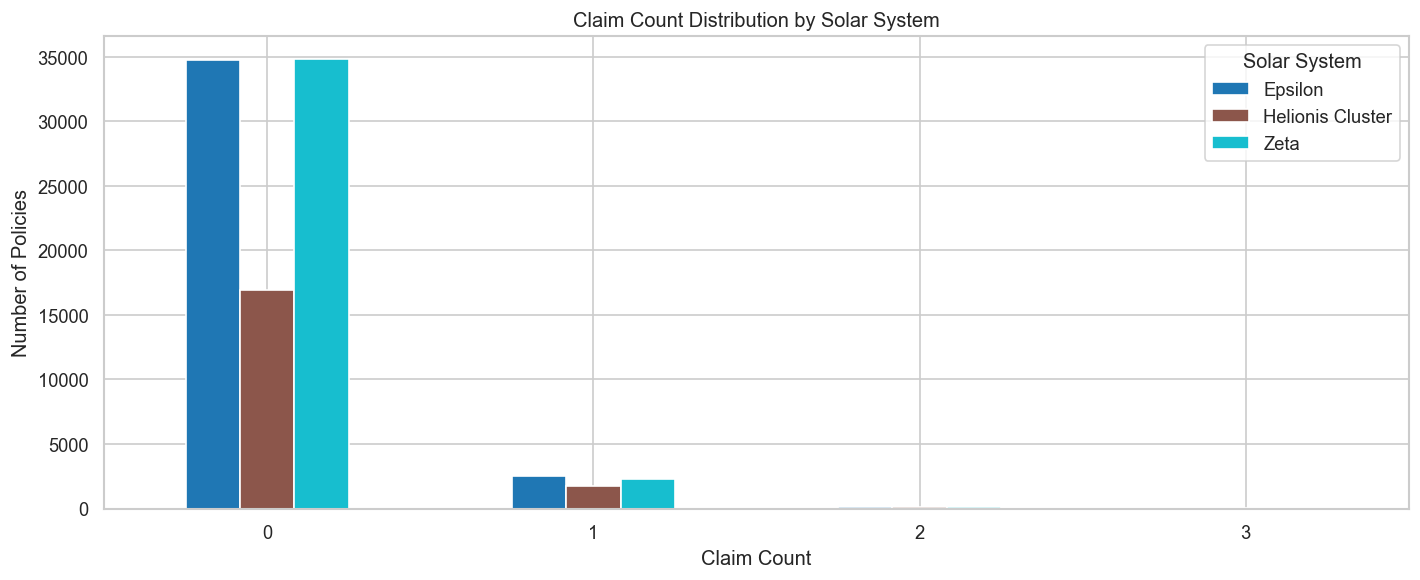

In [8]:
# Ensure claim_count is integer
freq_clean['claim_count'] = freq_clean['claim_count'].astype(int)

# Create pivot table: rows = claim_count, columns = solar_system
pivot = pd.crosstab(freq_clean['claim_count'], freq_clean['solar_system'])

# Plot grouped bar chart
pivot.plot(kind='bar', figsize=(12,5), colormap='tab10')

plt.title('Claim Count Distribution by Solar System')
plt.xlabel('Claim Count')
plt.ylabel('Number of Policies')
plt.xticks(rotation=0)
plt.legend(title='Solar System')
plt.tight_layout()
plt.show()

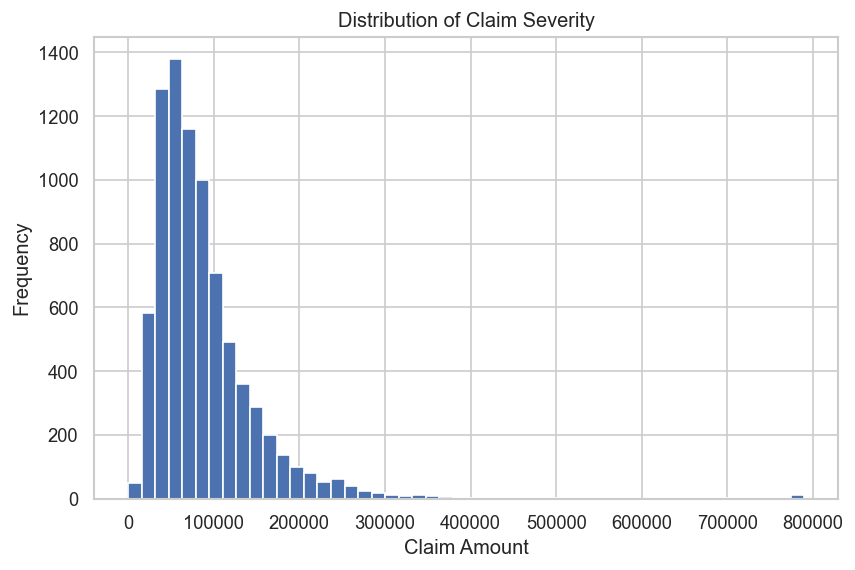

In [9]:
plt.figure(figsize=(8,5))
plt.hist(sev_clean['claim_amount'], bins=50)
plt.xlabel('Claim Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Claim Severity')
plt.show()


2. Exploratory Data Analysis (Clean Data)
2.1 Distribution of Numeric Features

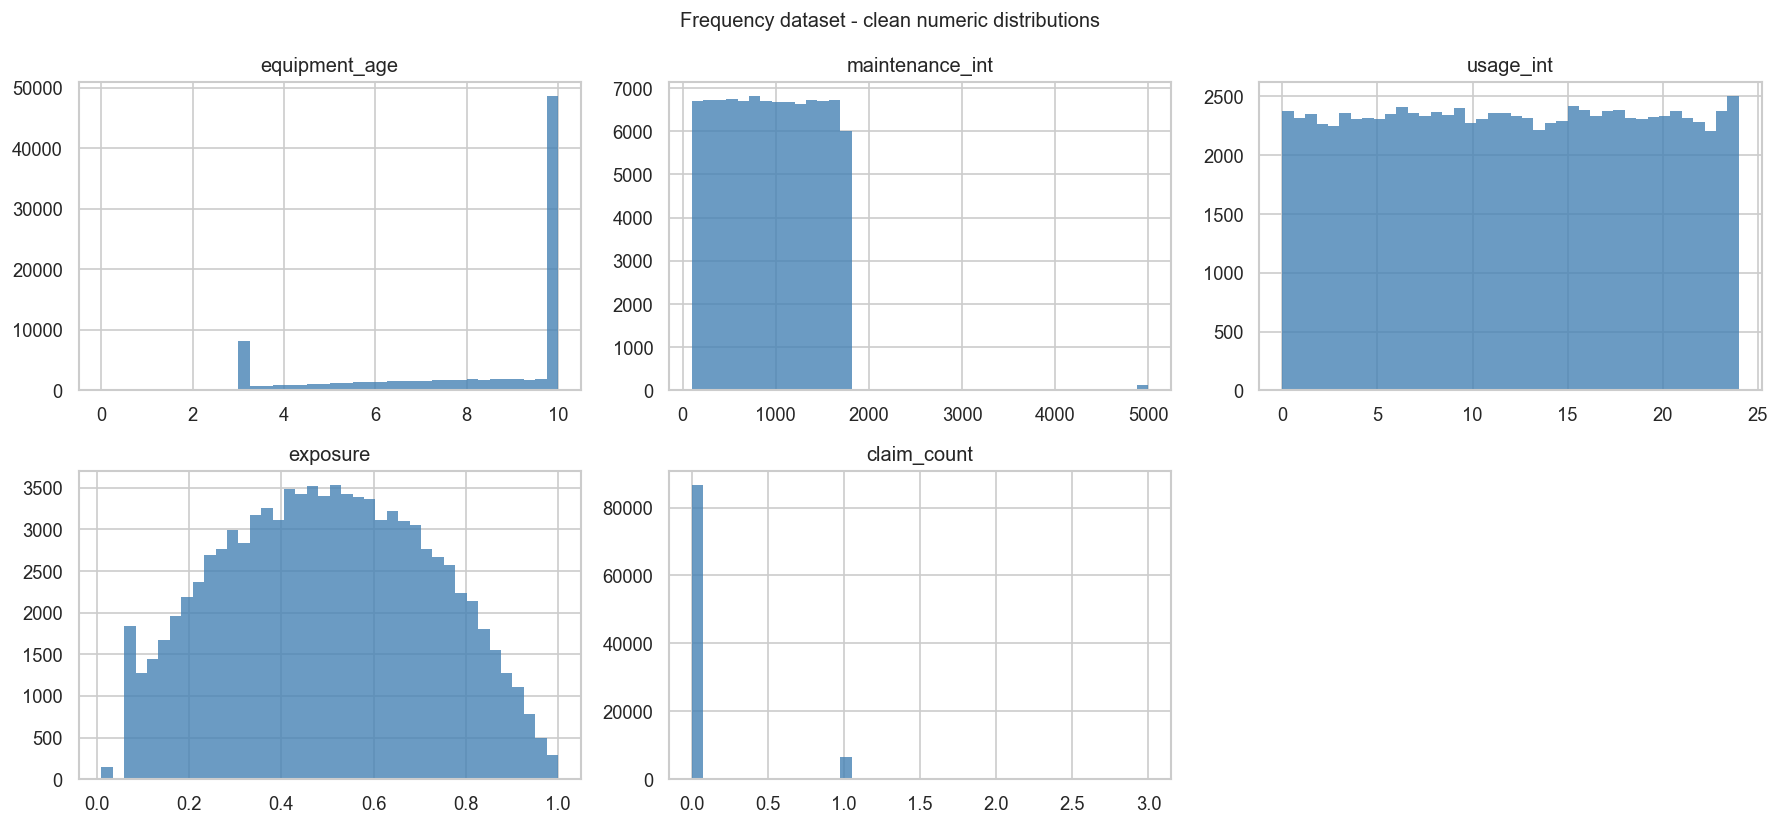

In [10]:
num_cols = [
    'equipment_age',
    'maintenance_int',
    'usage_int',   
    'exposure',
    'claim_count'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))  # 6 slots total
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col in freq_clean.columns:
        data = freq_clean[col].dropna()
        axes[i].hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
        axes[i].set_title(col)
    else:
        axes[i].set_visible(False)

# Hide any unused subplot
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Frequency dataset - clean numeric distributions', fontsize=12)
plt.tight_layout()
plt.show()

2.2 Claim Count Distribution

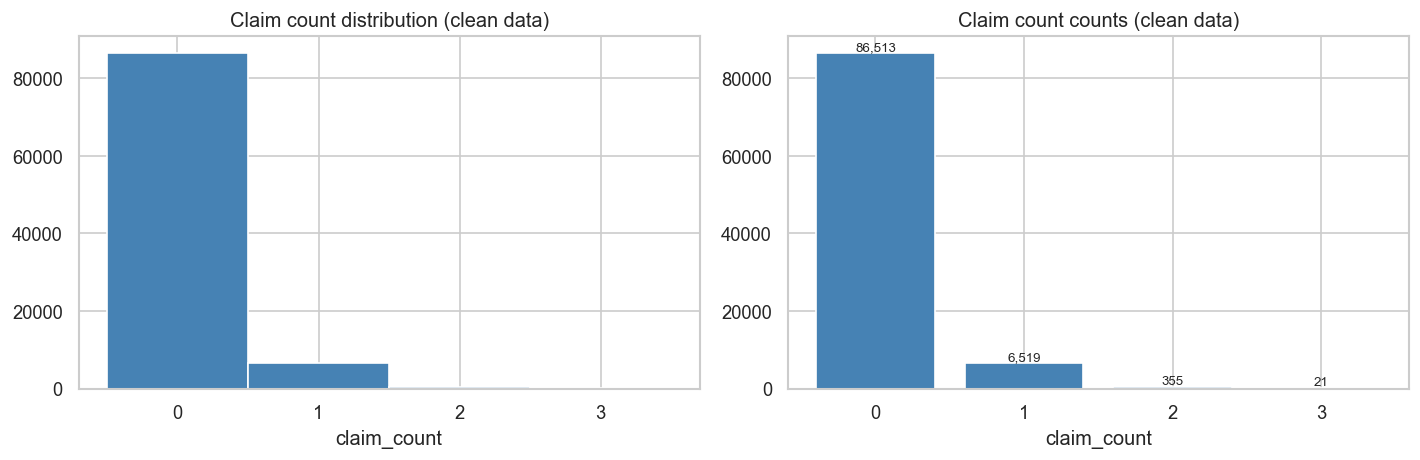

Claim count: {'count': 93408.0, 'mean': 0.07806611853374443, 'std': 0.2844690648857596, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 3.0}


In [11]:
cc = freq_clean['claim_count'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram with integer bins ---
bins = range(cc.min(), cc.max() + 2)  # integer bin edges
axes[0].hist(cc, bins=bins, color='steelblue', edgecolor='white', align='left')
axes[0].set_xticks(range(cc.min(), cc.max() + 1))  # force integer ticks
axes[0].set_title('Claim count distribution (clean data)')
axes[0].set_xlabel('claim_count')

# --- Bar chart ---
vc = cc.value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(vc.index)  # force integer ticks
for val in vc.index:
    axes[1].annotate(f'{vc[val]:,}', xy=(val, vc[val]),
                     ha='center', va='bottom', fontsize=8)

axes[1].set_title('Claim count counts (clean data)')
axes[1].set_xlabel('claim_count')

plt.tight_layout()
plt.show()

print(f'Claim count: {cc.describe().to_dict()}')

2.3 Claim Frequency and Severity across solar systems

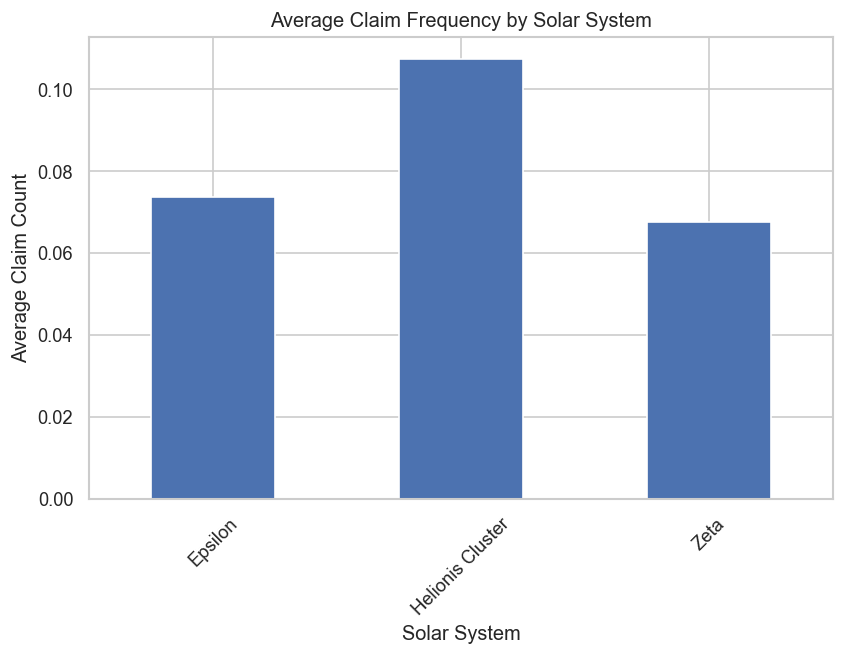

In [16]:
plt.figure(figsize=(8,5))

freq_clean.groupby('solar_system')['claim_count'].mean().plot(kind='bar')

plt.title('Average Claim Frequency by Solar System')
plt.xlabel('Solar System')
plt.ylabel('Average Claim Count')
plt.xticks(rotation=45)

plt.show()

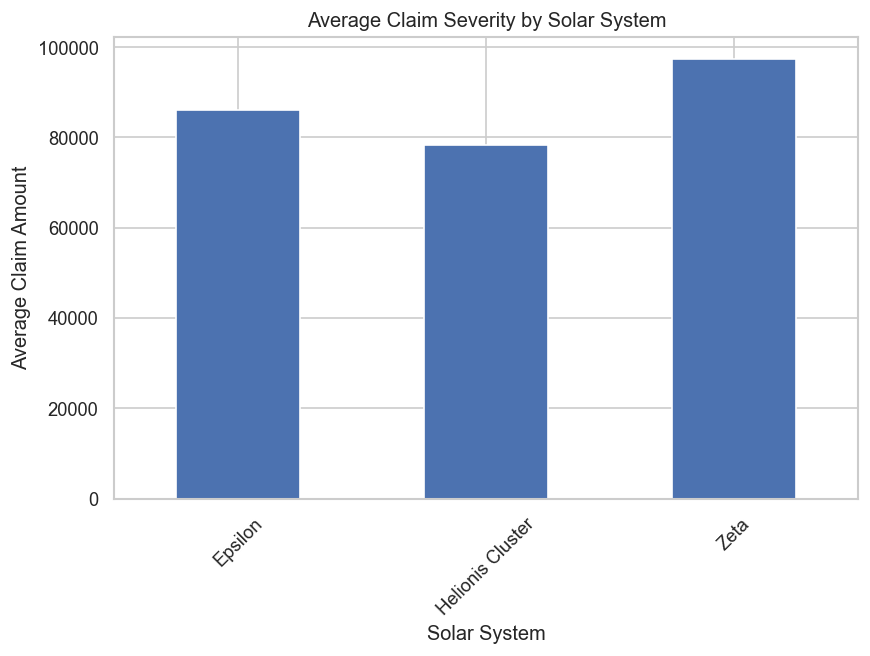

In [17]:
plt.figure(figsize=(8,5))

sev_clean.groupby('solar_system')['claim_amount'].mean().plot(kind='bar')

plt.title('Average Claim Severity by Solar System')
plt.xlabel('Solar System')
plt.ylabel('Average Claim Amount')
plt.xticks(rotation=45)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sev_clean.boxplot(column='claim_amount', by='solar_system')

plt.title('Claim Severity by Solar System')
plt.suptitle('')
plt.xlabel('Solar System')
plt.ylabel('Claim Amount')
plt.xticks(rotation=45)

plt.show()

2.4 Categorical Features

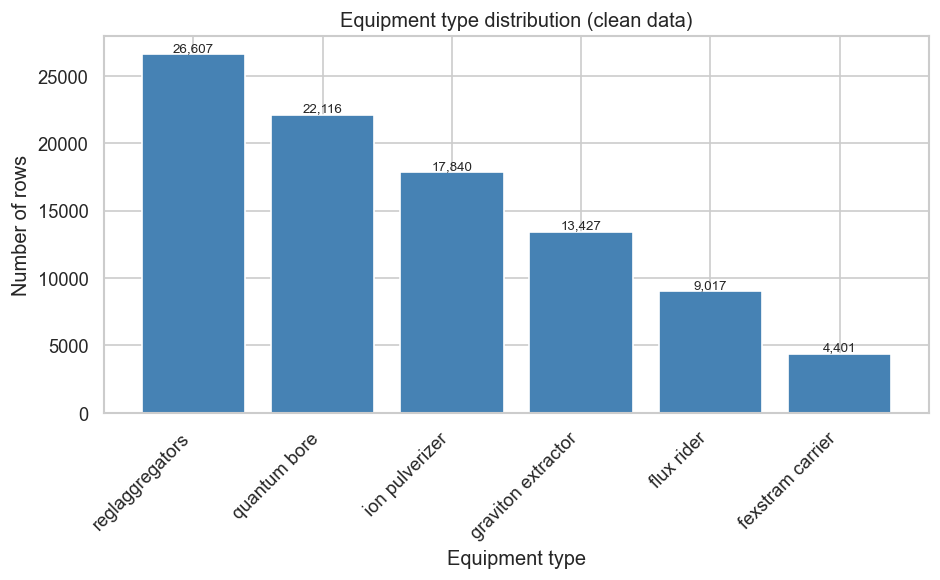

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

vc_equipment = (
    freq_clean['equipment_type']
    .str.strip()
    .str.lower()
    .value_counts()
)

ax.bar(range(len(vc_equipment)), vc_equipment.values,
       color='steelblue', edgecolor='white')

ax.set_xticks(range(len(vc_equipment)))
ax.set_xticklabels(vc_equipment.index, rotation=45, ha='right')

for j, (cat, cnt) in enumerate(vc_equipment.items()):
    ax.text(j, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=8)

ax.set_title('Equipment type distribution (clean data)')
ax.set_xlabel('Equipment type')
ax.set_ylabel('Number of rows')

plt.tight_layout()
plt.show()

2.5 Predictor vs Claim Rate (Clean Data)

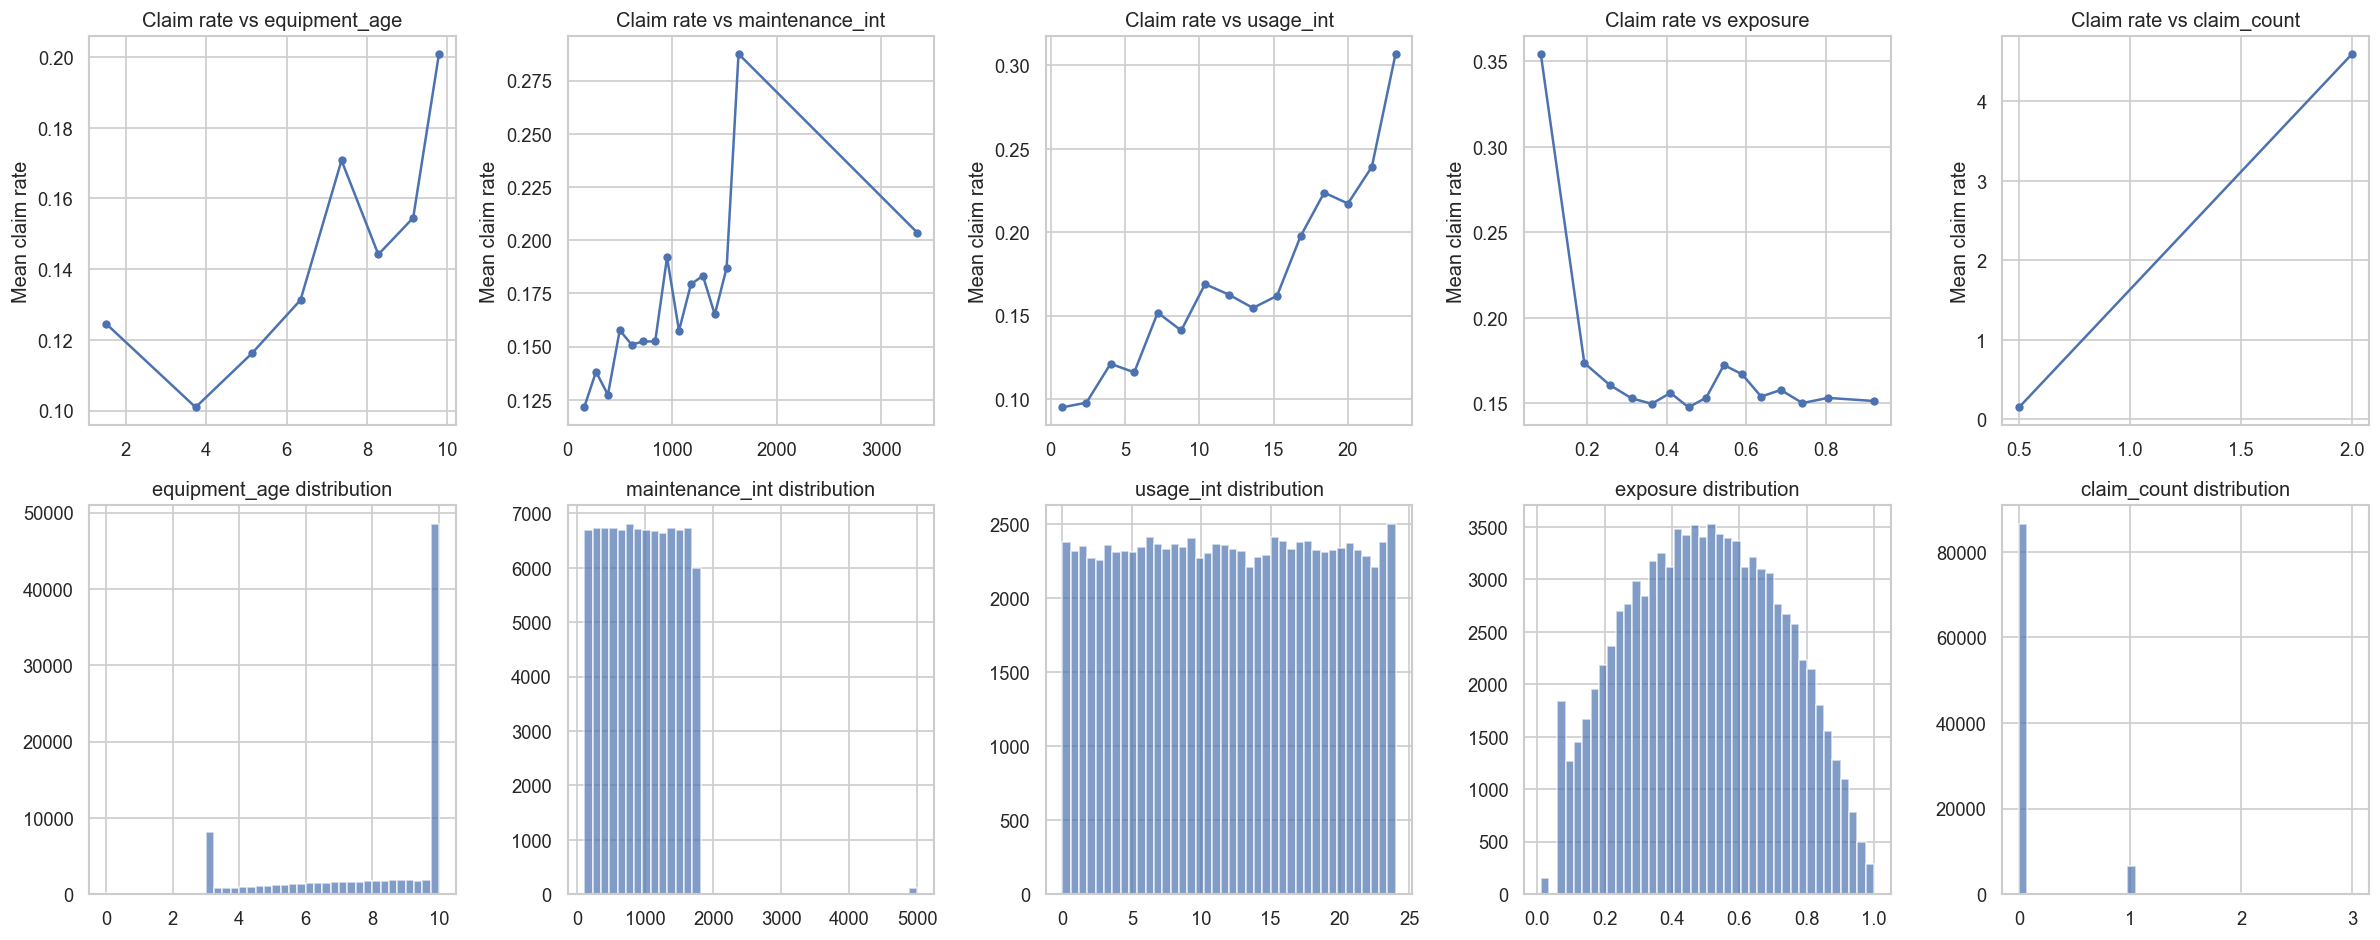

In [ ]:
freq_clean['claim_rate'] = freq_clean['claim_count'] / freq_clean['exposure']

cont_preds = [
    'equipment_age',
    'maintenance_int',
    'usage_int',   
    'exposure',
    'claim_count'
]

n = len(cont_preds)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for i, col in enumerate(cont_preds):
    sub = freq_clean[[col, 'claim_rate']].dropna().copy()

    sub['bin'] = pd.qcut(sub[col], q=15, duplicates='drop')
    grp = sub.groupby('bin', observed=True)['claim_rate'].mean().reset_index()
    grp['mid'] = grp['bin'].apply(lambda x: x.mid)

    # Top row: relationship
    axes[0, i].plot(grp['mid'], grp['claim_rate'], 'o-', ms=4)
    axes[0, i].set_title(f'Claim rate vs {col}')
    axes[0, i].set_ylabel('Mean claim rate')

    # Bottom row: distribution
    axes[1, i].hist(freq_clean[col].dropna(), bins=40, alpha=0.7)
    axes[1, i].set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

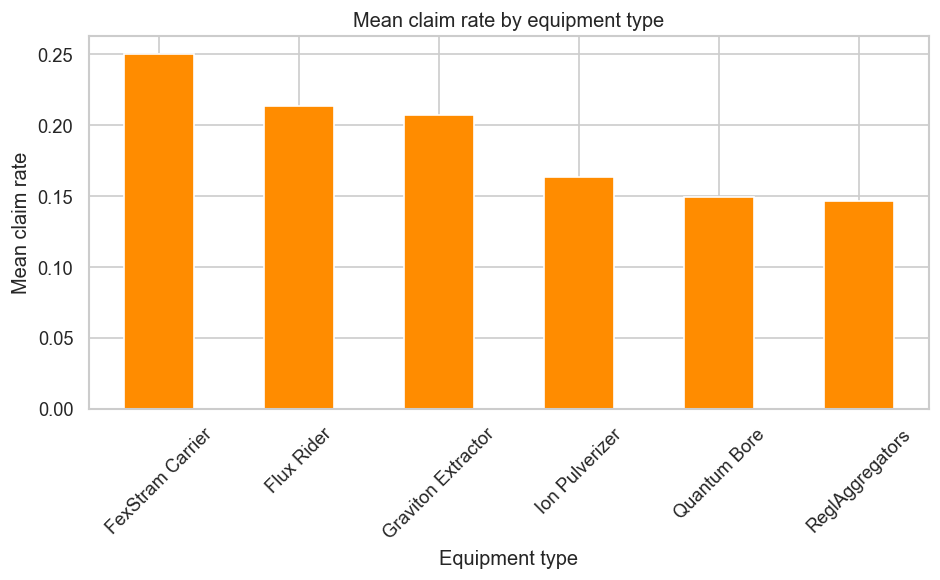

Mean claim rate by equipment type:
equipment_type
FexStram Carrier      0.250221
Flux Rider            0.213335
Graviton Extractor    0.206963
Ion Pulverizer        0.163114
Quantum Bore          0.149523
ReglAggregators       0.146239


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ct_rate = (
    freq_clean
    .groupby('equipment_type')['claim_rate']
    .mean()
    .sort_values(ascending=False)
)

ct_rate.plot.bar(color='darkorange', edgecolor='white', ax=ax)

ax.set_title('Mean claim rate by equipment type')
ax.set_xlabel('Equipment type')
ax.set_ylabel('Mean claim rate')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Mean claim rate by equipment type:')
print(ct_rate.to_string())

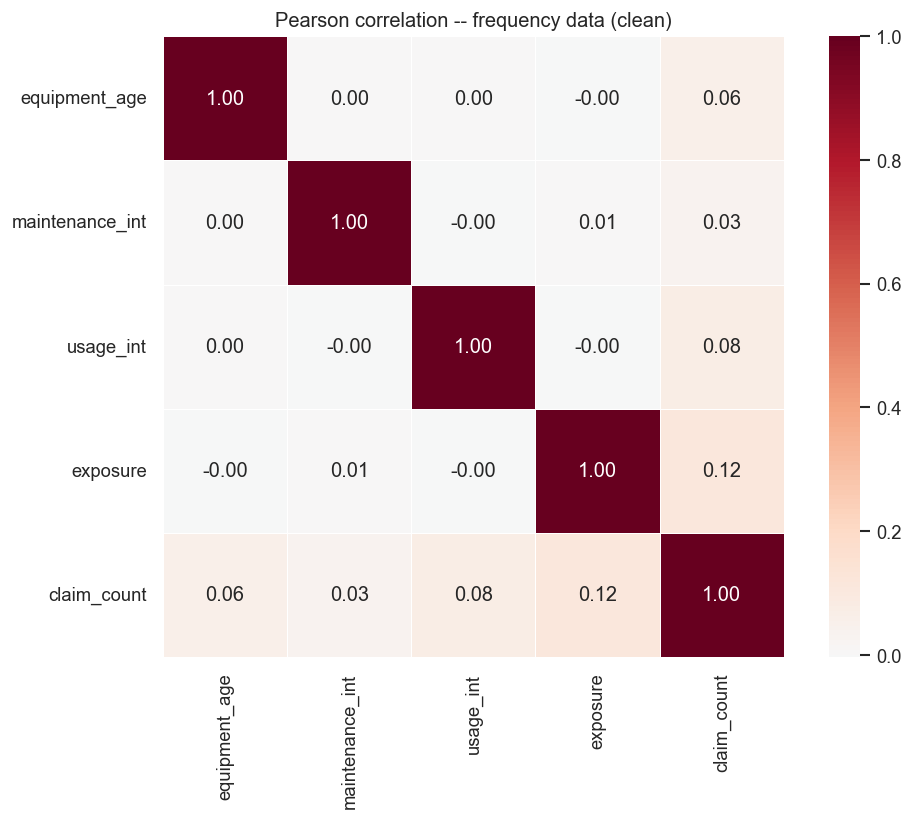

In [ ]:
corr_cols = [
    'equipment_age',
    'maintenance_int',
    'usage_int',   
    'exposure',
    'claim_count',
]
corr = freq_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation -- frequency data (clean)')
plt.tight_layout()
plt.show()

3. Frequency Model -- Poisson GLM

In [ ]:
# -----------------------------
# 1. Prepare the dataset
# -----------------------------
freq_model_df = freq_clean.copy()

# Exposure offset
freq_model_df['log_exposure'] = np.log(freq_model_df['exposure'])

# Standardize continuous predictors
cont_preds = ['equipment_age', 'maintenance_int', 'usage_int']
freq_std = {}
for col in cont_preds:
    mu = freq_model_df[col].mean()
    sd = freq_model_df[col].std()
    freq_std[col] = {'mean': mu, 'std': sd}
    freq_model_df[f'{col}_z'] = (freq_model_df[col] - mu) / sd
    print(f'{col}: mean={mu:.4f}, std={sd:.4f}')

# Categorical predictors
freq_model_df['equipment_type_cat'] = freq_model_df['equipment_type'].str.strip().str.lower()
freq_model_df['solar_system_cat'] = freq_model_df['solar_system'].str.strip().str.lower()

# Optional: collapse rare equipment types
rare_eq = {'fexstram carrier'}
freq_model_df['equipment_type_cat'] = freq_model_df['equipment_type_cat'].apply(
    lambda x: 'reglaggregators' if x in rare_eq else x
)

# Drop rows missing any model variable
mvars = ['claim_count', 'exposure'] + [f'{c}_z' for c in cont_preds] + ['equipment_type_cat', 'solar_system_cat']
freq_model_df = freq_model_df.dropna(subset=mvars)
print(f'\nFrequency model rows: {len(freq_model_df):,}')

# -----------------------------
# 2. Fit Poisson GLM
# -----------------------------
freq_formula = (
    'claim_count ~ '
    'C(equipment_type_cat, Treatment(reference="reglaggregators")) + '
    'C(solar_system_cat, Treatment(reference="helionis cluster")) + '
    'equipment_age_z + maintenance_int_z + usage_int_z'
)

freq_glm = smf.glm(
    formula=freq_formula,
    data=freq_model_df,
    family=sm.families.Poisson(),
    offset=freq_model_df['log_exposure']
).fit()

# -----------------------------
# 3. Model summary
# -----------------------------
print(freq_glm.summary())

# Optional: exponentiated coefficients for multiplicative interpretation
coef_df = pd.DataFrame({
    'coef': freq_glm.params,
    'exp(coef)': np.exp(freq_glm.params),
    'p_value': freq_glm.pvalues
}).sort_values('p_value')

print('\nExponentiated coefficients (multiplicative effect on expected claim count):')
print(coef_df.to_string())

equipment_age: mean=8.1834, std=2.4432
maintenance_int: mean=956.2496, std=513.8354
usage_int: mean=12.0088, std=6.9350

Frequency model rows: 93,408
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                93408
Model:                            GLM   Df Residuals:                    93398
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -24779.
Date:                Fri, 13 Mar 2026   Deviance:                       35530.
Time:                        10:49:00   Pearson chi2:                 1.02e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01455
Covariance Type:            nonrobust                                         
                                                            

Exposure is included as a log offset in the Poisson GLM so that the model estimates the claim frequency per unit of exposure while ensuring that expected claim counts scale proportionally with the amount of exposure.

In [ ]:
# -----------------------------
# Dispersion check
# -----------------------------
dispersion = freq_glm.deviance / freq_glm.df_resid

print(f"Model Deviance: {freq_glm.deviance:.4f}")
print(f"Residual DF: {freq_glm.df_resid}")
print(f"Dispersion (Deviance / DF): {dispersion:.4f}")

pearson_dispersion = sum(freq_glm.resid_pearson**2) / freq_glm.df_resid
print(f"Pearson Dispersion: {pearson_dispersion:.4f}")

Model Deviance: 35530.0105
Residual DF: 93398
Dispersion (Deviance / DF): 0.3804
Pearson Dispersion: 1.0956


The dispersion of the Poisson GLM was assessed using the Pearson statistic. The Pearson dispersion was 1.0956, which is very close to 1, indicating that the Poisson variance assumption is appropriate and there is no evidence of overdispersion in the claim frequency data.

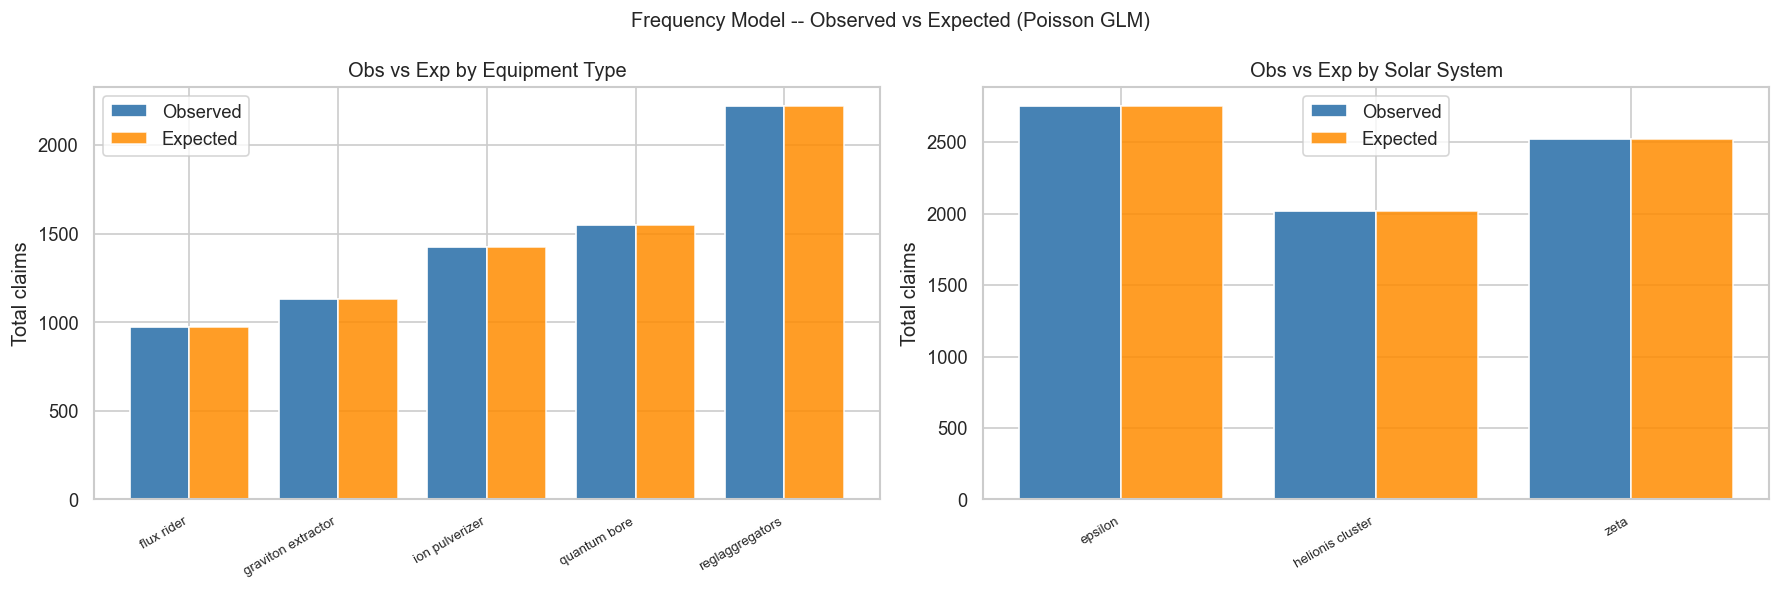

In [ ]:
freq_model_df['fitted_mu'] = freq_glm.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(15, 5))  

for ax, col, title in zip(
        axes,
        ['equipment_type_cat', 'solar_system_cat'],
        ['Equipment Type', 'Solar System']):
    grp = freq_model_df.groupby(col).agg(
        obs=('claim_count', 'sum'),
        exp=('fitted_mu', 'sum')
    ).reset_index()
    x = np.arange(len(grp))
    ax.bar(x - 0.2, grp['obs'], 0.4, label='Observed', color='steelblue')
    ax.bar(x + 0.2, grp['exp'], 0.4, label='Expected', color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(grp[col].astype(str), rotation=30, ha='right', fontsize=8)
    ax.set_title(f'Obs vs Exp by {title}')
    ax.set_ylabel('Total claims')
    ax.legend()

plt.suptitle('Frequency Model -- Observed vs Expected (Poisson GLM)', fontsize=12)
plt.tight_layout()
plt.show()

Incidence Rate Ratios (IRR = exp(coef)):
                                                                                       coef     IRR  IRR_lb  IRR_ub  p_value
Intercept                                                                           -1.6930  0.1840  0.1739  0.1946   0.0000
C(equipment_type_cat, Treatment(reference="reglaggregators"))[T.flux rider]          0.4084  1.5044  1.3952  1.6223   0.0000
C(equipment_type_cat, Treatment(reference="reglaggregators"))[T.graviton extractor]  0.1726  1.1883  1.1062  1.2765   0.0000
C(equipment_type_cat, Treatment(reference="reglaggregators"))[T.ion pulverizer]      0.1069  1.1128  1.0411  1.1894   0.0017
C(equipment_type_cat, Treatment(reference="reglaggregators"))[T.quantum bore]       -0.0218  0.9784  0.9169  1.0441   0.5105
C(solar_system_cat, Treatment(reference="helionis cluster"))[T.epsilon]             -0.3802  0.6837  0.6456  0.7241   0.0000
C(solar_system_cat, Treatment(reference="helionis cluster"))[T.zeta]                

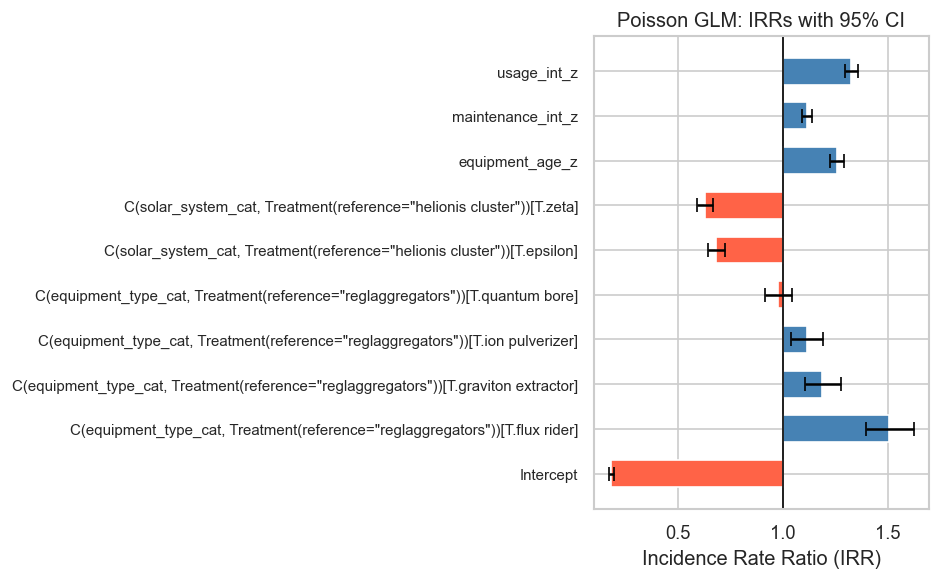

In [ ]:
# -----------------------------
# 1. Create IRR table
# -----------------------------
coef_df = pd.DataFrame({
    'coef':    freq_glm.params,
    'IRR':     np.exp(freq_glm.params),
    'IRR_lb':  np.exp(freq_glm.conf_int()[0]),
    'IRR_ub':  np.exp(freq_glm.conf_int()[1]),
    'p_value': freq_glm.pvalues
})

print('Incidence Rate Ratios (IRR = exp(coef)):')
print(coef_df.round(4).to_string())

# -----------------------------
# 2. Plot IRRs with 95% CI
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_df))

# Horizontal bar plot
ax.barh(
    y_pos,
    coef_df['IRR'] - 1,
    left=1,
    color=['steelblue' if v > 0 else 'tomato' for v in (coef_df['IRR'] - 1)],
    edgecolor='white',
    height=0.6
)

# Error bars
ax.errorbar(
    coef_df['IRR'], y_pos,
    xerr=[coef_df['IRR'] - coef_df['IRR_lb'], coef_df['IRR_ub'] - coef_df['IRR']],
    fmt='none', color='black', capsize=4, lw=1.5
)

ax.axvline(1, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index, fontsize=9)
ax.set_xlabel('Incidence Rate Ratio (IRR)')
ax.set_title('Poisson GLM: IRRs with 95% CI')
plt.tight_layout()
plt.show()

4. Severity Model

In [ ]:
# -----------------------------
# 1. Prepare severity dataset
# -----------------------------
sev_model_df = sev_clean.copy()

# Severity model should only use positive claims
sev_model_df = sev_model_df[sev_model_df['claim_amount'] > 0]

# Remove extreme outliers (top 1%)
upper = sev_model_df['claim_amount'].quantile(0.99)
sev_model_df = sev_model_df[sev_model_df['claim_amount'] <= upper]

# Clean categorical predictors
sev_model_df['equipment_type_cat'] = sev_model_df['equipment_type'].str.strip().str.lower()
sev_model_df['solar_system_cat'] = sev_model_df['solar_system'].str.strip().str.lower()

# -----------------------------
# 2. Standardise predictors
# -----------------------------
sev_std = {}

for col in ['equipment_age', 'usage_int']:
    mu = sev_model_df[col].mean()
    sd = sev_model_df[col].std()
    sev_std[col] = {'mean': mu, 'std': sd}
    sev_model_df[f'{col}_z'] = (sev_model_df[col] - mu) / sd

# Drop missing
mvars_sev = [
    'claim_amount',
    'equipment_type_cat',
    'solar_system_cat',
    'equipment_age_z',
    'usage_int_z'
]

sev_model_df = sev_model_df.dropna(subset=mvars_sev)

print(f'Severity model rows: {len(sev_model_df):,}')

# -----------------------------
# 3. Improved formula
# -----------------------------
sev_formula = (
    'claim_amount ~ C(equipment_type_cat)'
    ' + C(solar_system_cat)'
    ' + equipment_age_z'
    ' + usage_int_z'
)

# -----------------------------
# 4. Fit Gamma GLM
# -----------------------------
sev_glm = smf.glm(
    formula=sev_formula,
    data=sev_model_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(sev_glm.summary())

# -----------------------------
# 5. Fitted values
# -----------------------------
sev_model_df['fitted_mu'] = sev_glm.fittedvalues

# Dispersion
dispersion = sev_glm.deviance / sev_glm.df_resid
print("Gamma dispersion:", dispersion)

Severity model rows: 7,992
                 Generalized Linear Model Regression Results                  
Dep. Variable:           claim_amount   No. Observations:                 7992
Model:                            GLM   Df Residuals:                     7982
Model Family:                   Gamma   Df Model:                            9
Link Function:                    log   Scale:                         0.25104
Method:                          IRLS   Log-Likelihood:                -95038.
Date:                Fri, 13 Mar 2026   Deviance:                       1846.1
Time:                        10:49:00   Pearson chi2:                 2.00e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.2962
Covariance Type:            nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

Maintenance age is not a statistically significant indicator

Exposure is not included in the severity model because exposure affects the number of claims occurring (frequency) rather than the size of a claim once it occurs. Therefore, exposure is accounted for in the frequency model through an offset, while the severity model focuses only on the distribution of claim amounts for observed claims.

A Gamma dispersion of 0.231 is very good for a severity model.

For a Gamma GLM, the dispersion parameter measures how much variance remains after the model explains the data.

Severity model -- coefficients (log scale) and multiplicative effects:
                                                coef    Exp_coef          lb          ub  p_value
Intercept                                    10.7841  48247.4505  46257.1355  50323.4033      0.0
C(equipment_type_cat)[T.flux rider]           0.2048      1.2273      1.1680      1.2896      0.0
C(equipment_type_cat)[T.graviton extractor]   0.4214      1.5241      1.4522      1.5997      0.0
C(equipment_type_cat)[T.ion pulverizer]       0.5458      1.7261      1.6474      1.8084      0.0
C(equipment_type_cat)[T.quantum bore]         0.8935      2.4437      2.3330      2.5598      0.0
C(equipment_type_cat)[T.reglaggregators]      0.5202      1.6824      1.6073      1.7610      0.0
C(solar_system_cat)[T.helionis cluster]      -0.0974      0.9072      0.8828      0.9323      0.0
C(solar_system_cat)[T.zeta]                   0.1148      1.1216      1.0927      1.1513      0.0
equipment_age_z                               0

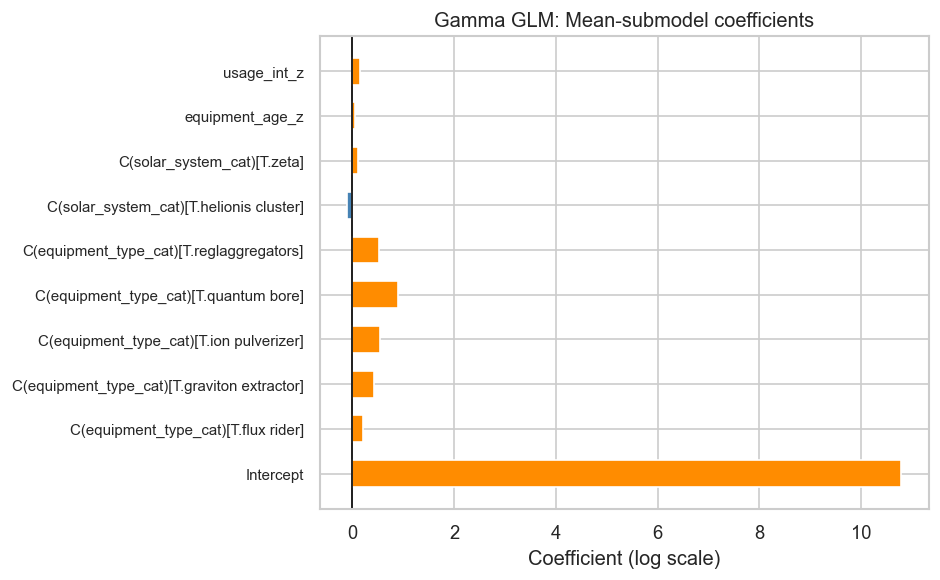

In [ ]:
# -----------------------------
# Coefficient table for Gamma GLM
# -----------------------------
coef_sev_df = pd.DataFrame({
    'coef':    sev_glm.params,
    'Exp_coef': np.exp(sev_glm.params),  # multiplicative effect on claim amount
    'lb':      np.exp(sev_glm.conf_int()[0]),
    'ub':      np.exp(sev_glm.conf_int()[1]),
    'p_value': sev_glm.pvalues
})

print('Severity model -- coefficients (log scale) and multiplicative effects:')
print(coef_sev_df.round(4).to_string())

# -----------------------------
# Horizontal bar plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coef_sev_df))

ax.barh(
    y_pos, coef_sev_df['coef'],
    color=['darkorange' if v>0 else 'steelblue' for v in coef_sev_df['coef']],
    edgecolor='white', height=0.6
)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_sev_df.index, fontsize=9)
ax.set_xlabel('Coefficient (log scale)')
ax.set_title('Gamma GLM: Mean-submodel coefficients')
plt.tight_layout()
plt.show()

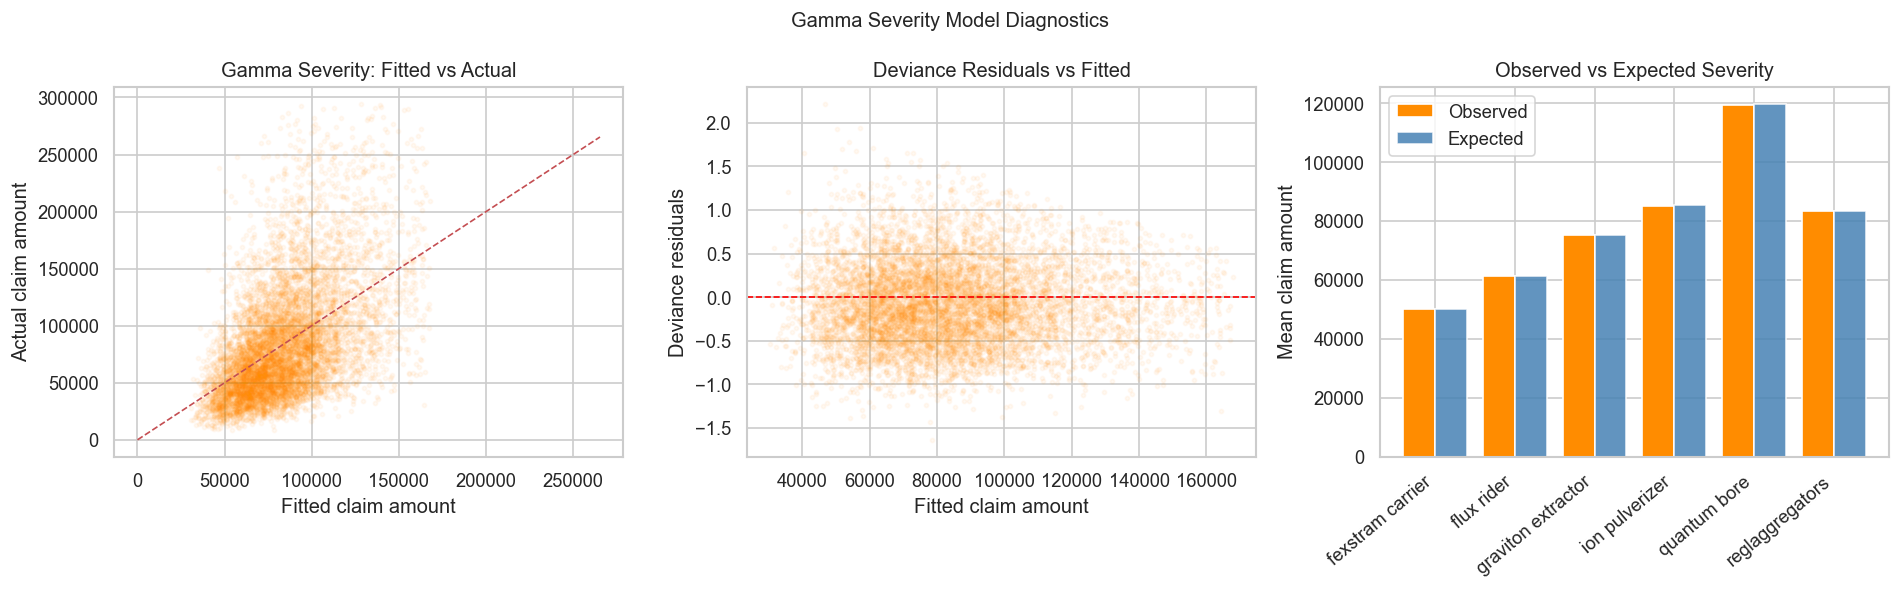

In [ ]:
# -----------------------------------
# 1. Add fitted values and residuals
# -----------------------------------
sev_model_df['fitted_mu'] = sev_glm.fittedvalues
sev_model_df['resid_dev'] = sev_glm.resid_deviance
sev_model_df['resid_pearson'] = sev_glm.resid_pearson

fig, axes = plt.subplots(1, 3, figsize=(16,5))

# -----------------------------------
# 2. Fitted vs Actual
# -----------------------------------
lim = sev_model_df['claim_amount'].quantile(0.995)

axes[0].scatter(sev_model_df['fitted_mu'], sev_model_df['claim_amount'],
                alpha=0.05, s=6, color='darkorange')

axes[0].plot([0, lim], [0, lim], 'r--', lw=1)

axes[0].set_title('Gamma Severity: Fitted vs Actual')
axes[0].set_xlabel('Fitted claim amount')
axes[0].set_ylabel('Actual claim amount')


# -----------------------------------
# 3. Residuals vs Fitted
# -----------------------------------
axes[1].scatter(sev_model_df['fitted_mu'], sev_model_df['resid_dev'],
                alpha=0.05, s=6, color='darkorange')

axes[1].axhline(0, color='red', ls='--', lw=1)

axes[1].set_title('Deviance Residuals vs Fitted')
axes[1].set_xlabel('Fitted claim amount')
axes[1].set_ylabel('Deviance residuals')


# -----------------------------------
# 4. Observed vs Expected by category
# -----------------------------------
grp = sev_model_df.groupby('equipment_type_cat').agg(
    obs=('claim_amount','mean'),
    exp=('fitted_mu','mean')
).reset_index()

x = np.arange(len(grp))

axes[2].bar(x-0.2, grp['obs'], 0.4, label='Observed', color='darkorange')
axes[2].bar(x+0.2, grp['exp'], 0.4, label='Expected', color='steelblue', alpha=0.85)

axes[2].set_xticks(x)
axes[2].set_xticklabels(grp['equipment_type_cat'], rotation=40, ha='right')

axes[2].set_title('Observed vs Expected Severity')
axes[2].set_ylabel('Mean claim amount')
axes[2].legend()

plt.suptitle('Gamma Severity Model Diagnostics', fontsize=12)
plt.tight_layout()
plt.show()

5. Pricing Model

Premium = Expected Frequency×Expected Severity

In [ ]:
pricing_df = freq_model_df.copy()
pricing_df['pred_claims'] = freq_glm.predict(
    pricing_df,
    offset=np.log(pricing_df['exposure'])
)

# Convert to claim rate
pricing_df['freq_rate'] = pricing_df['pred_claims'] / pricing_df['exposure']

pricing_df['pred_severity'] = sev_glm.predict(pricing_df)

pricing_df['pure_premium'] = (
    pricing_df['freq_rate'] *
    pricing_df['pred_severity']
)

expense_loading = 0.15
profit_loading = 0.10

pricing_df['technical_premium'] = (
    pricing_df['pure_premium'] *
    (1 + expense_loading + profit_loading)
)

pricing_summary = pricing_df.groupby(
    ['solar_system_cat','equipment_type_cat']
).agg(
    pure_premium=('pure_premium','mean'),
    technical_premium=('technical_premium','mean')
).reset_index()

# -----------------------------
# Add expected frequency and severity
# -----------------------------
pricing_summary = pricing_df.groupby(
    ['solar_system_cat', 'equipment_type_cat']
).agg(
    expected_frequency=('freq_rate', 'mean'),
    expected_severity=('pred_severity', 'mean'),
    pure_premium=('pure_premium', 'mean'),
    technical_premium=('technical_premium', 'mean')
).reset_index()

# Round for readability
pricing_summary[['expected_frequency','expected_severity','pure_premium','technical_premium']] = \
    pricing_summary[['expected_frequency','expected_severity','pure_premium','technical_premium']].round(2)


print(pricing_summary)

    solar_system_cat  equipment_type_cat  expected_frequency  \
0            epsilon          flux rider                0.20   
1            epsilon  graviton extractor                0.16   
2            epsilon      ion pulverizer                0.15   
3            epsilon        quantum bore                0.13   
4            epsilon     reglaggregators                0.13   
5   helionis cluster          flux rider                0.30   
6   helionis cluster  graviton extractor                0.23   
7   helionis cluster      ion pulverizer                0.22   
8   helionis cluster        quantum bore                0.19   
9   helionis cluster     reglaggregators                0.20   
10              zeta          flux rider                0.19   
11              zeta  graviton extractor                0.15   
12              zeta      ion pulverizer                0.14   
13              zeta        quantum bore                0.12   
14              zeta     reglaggregators

In [ ]:
# -----------------------------------
# 2. Predicted frequency
# -----------------------------------
pricing_df['pred_claims'] = freq_glm.predict(
    pricing_df,
    offset=np.log(pricing_df['exposure'])
)

# Convert to claim rate
pricing_df['freq_rate'] = pricing_df['pred_claims'] / pricing_df['exposure']

print("\nFrequency prediction summary")
print(pricing_df['freq_rate'].describe())


Frequency prediction summary
count    93408.000000
mean         0.156346
std          0.070426
min          0.030485
25%          0.105239
50%          0.142368
75%          0.192955
max          1.161451
Name: freq_rate, dtype: float64


In [ ]:
# -----------------------------------
# 3. Predicted severity
# -----------------------------------
pricing_df['pred_severity'] = sev_glm.predict(pricing_df)

print("\nSeverity prediction summary")
print(pricing_df['pred_severity'].describe())


Severity prediction summary
count     93408.000000
mean      90669.759525
std       24879.257392
min       37822.345606
25%       72444.813173
50%       86405.392016
75%      104447.268631
max      175161.158980
Name: pred_severity, dtype: float64


In [ ]:
# -----------------------------------
# 4. Pure premium
# -----------------------------------
pricing_df['pure_premium'] = (
    pricing_df['freq_rate'] *
    pricing_df['pred_severity']
)

print("\nPure premium summary")
print(pricing_df['pure_premium'].describe())


Pure premium summary
count    93408.000000
mean     14380.389923
std       7853.877979
min       1946.412693
25%       8448.976543
50%      12493.022378
75%      18732.244482
max      85357.376560
Name: pure_premium, dtype: float64


In [ ]:
# -----------------------------------
# 5. Technical premium
# -----------------------------------
expense_loading = 0.25
profit_loading = 0.10

pricing_df['technical_premium'] = (
    pricing_df['pure_premium'] *
    (1 + expense_loading + profit_loading)
)

print("\nTechnical premium summary")
print(pricing_df['technical_premium'].describe())


Technical premium summary
count     93408.000000
mean      19413.526396
std       10602.735271
min        2627.657135
25%       11406.118332
50%       16865.580211
75%       25288.530051
max      115232.458356
Name: technical_premium, dtype: float64


In [ ]:
# -----------------------------------
# 6. Pricing summary by solar system
# -----------------------------------
pricing_solar = pricing_df.groupby('solar_system_cat').agg(
    avg_pure_premium=('pure_premium','mean'),
    avg_technical_premium=('technical_premium','mean'),
    avg_freq=('freq_rate','mean'),
    avg_severity=('pred_severity','mean')
).reset_index()

print("\nPricing by Solar System")
print(pricing_solar)


Pricing by Solar System
   solar_system_cat  avg_pure_premium  avg_technical_premium  avg_freq  \
0           epsilon      13340.667542           18009.901182  0.147409   
1  helionis cluster      17696.015814           23889.621349  0.215613   
2              zeta      13749.988959           18562.485095  0.135406   

   avg_severity  
0  87998.646487  
1  79851.913782  
2  98805.094897  


In [ ]:
# -----------------------------------
# 7. Pricing summary by equipment
# -----------------------------------
pricing_equipment = pricing_df.groupby('equipment_type_cat').agg(
    avg_pure_premium=('pure_premium','mean'),
    avg_technical_premium=('technical_premium','mean'),
    avg_freq=('freq_rate','mean'),
    avg_severity=('pred_severity','mean')
).reset_index()

print("\nPricing by Equipment Type")
print(pricing_equipment)


Pricing by Equipment Type
   equipment_type_cat  avg_pure_premium  avg_technical_premium  avg_freq  \
0          flux rider      13807.332500           18639.898875  0.215876   
1  graviton extractor      13447.104717           18153.591368  0.169842   
2      ion pulverizer      14328.004369           19342.805899  0.159444   
3        quantum bore      17857.248378           24107.285310  0.140289   
4     reglaggregators      12501.482413           16877.001257  0.142862   

    avg_severity  
0   61701.442384  
1   76467.832486  
2   86816.853175  
3  122915.229271  
4   84461.414271  


In [ ]:
# -----------------------------------
# 8. Portfolio expected loss
# -----------------------------------
portfolio_loss = pricing_df['pure_premium'].sum()

print("\nExpected Portfolio Loss:", round(portfolio_loss,2))


Expected Portfolio Loss: 1343243461.91


In [ ]:
# -----------------------------------
# 9. Aggregate loss simulation
# -----------------------------------
n_sim = 50000

mean_freq = pricing_df['freq_rate'].mean()
mean_sev = pricing_df['pred_severity'].mean()

# Gamma dispersion from severity model
dispersion = sev_glm.deviance / sev_glm.df_resid

shape = 1 / dispersion
scale = mean_sev * dispersion

freq_sim = np.random.poisson(mean_freq, n_sim)
sev_sim = np.random.gamma(shape, scale, n_sim)

agg_loss = freq_sim * sev_sim

print("\nSimulated Loss Distribution")
print("Mean loss:", round(agg_loss.mean(),2))
print("95th percentile:", round(np.percentile(agg_loss,95),2))
print("99th percentile (1-in-100 event):", round(np.percentile(agg_loss,99),2))


Simulated Loss Distribution
Mean loss: 14059.14
95th percentile: 106262.62
99th percentile (1-in-100 event): 180320.28


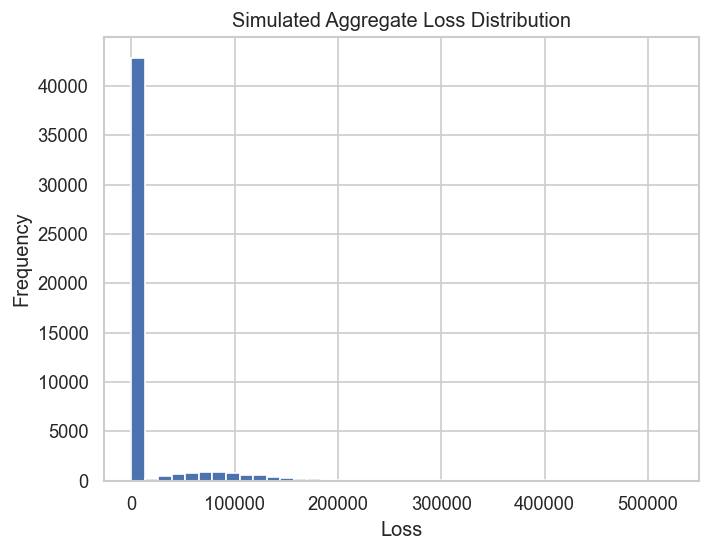

In [ ]:
# -----------------------------------
# 10. Plot loss distribution
# -----------------------------------
plt.hist(agg_loss, bins=40)
plt.title("Simulated Aggregate Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.show()